# ¿La inversión en marketing genera más ingresos?

Este informe analiza el desempeño comercial de una empresa a partir de 60.000 operaciones de venta registradas entre 2020 y 2023.

Buscamos responder una pregunta concreta de negocio: **¿invertir más en
marketing y publicidad se traduce en mayores ingresos por venta?** Para
responderla, exploramos los datos, los preparamos y analizamos la relación
entre la inversión en marketing y los ingresos generados.

## 1. Los datos

Trabajamos con una tabla de 60.000 registros y 23 columnas. Cada fila representa
una operación de venta e incluye:

- **Inversión en marketing:** presupuesto total y gasto en publicidad online y offline.
- **Características del cliente:** edad, segmento, nivel de satisfacción.
- **Contexto de la venta:** canal, categoría de producto, temporada y región.
- **Resultado:** los ingresos generados por la venta.

Nuestra variable de interés es el **ingreso por venta**, y las variables que
sospechamos que influyen son las de **inversión en marketing**.

In [1]:
# Antes de comenzar nuestro análisis, importamos todas las librerías vistas en clase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/raw/marketing_sales_dataset.csv")
pd.set_option('display.max_columns', None)

df.head(10)      # muestra las 10 primeras filas

,id,date,region,sales_channel,product_category,customer_segment,season,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,num_promotions,discount_percentage,num_sales_representatives,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
0,1,2020-11-12,Riyadh,Retail Store,Cosmetics,Regular,Q4,1664.51,952.30,326.97,5,23.4,24,42,4.5,0.76,1952,0.1193,0.0410,2034,25.0,6,3772.90
1,2,2022-07-05,Dubai,Online,Cosmetics,New,Q3,2452.29,1014.25,414.76,4,6.0,48,24,3.7,1.07,3185,0.0404,0.3166,2058,187.0,7,2091.36
2,3,2020-11-11,Riyadh,Online,Electronics,Regular,Q4,1026.13,328.30,242.72,8,11.5,12,32,2.0,1.18,1304,0.1459,0.3033,417,139.0,3,6201.11
3,4,2022-10-01,Cairo,Online,Electronics,Regular,Q4,1102.86,628.30,204.58,1,26.7,32,62,2.6,0.86,1609,0.0460,0.1138,20618,308.0,6,4911.38
4,5,2023-12-12,Cairo,Retail Store,Food & Beverage,Corporate,Q4,2517.55,777.24,817.88,6,38.8,35,23,3.0,1.01,366639,0.1670,0.1826,57116,97.0,6,7705.73
5,6,2022-11-28,Cairo,Retail Store,Food & Beverage,New,Q4,2108.13,942.07,411.53,7,39.7,31,44,2.7,0.81,7947,0.0147,0.1524,60085,202.0,2,1440.32
6,7,2023-04-02,Riyadh,Direct Sales,Home Appliances,Regular,Q2,14301.40,3329.74,3229.64,1,34.0,44,56,3.5,1.19,51772,0.0166,0.2131,4772,65.0,9,4199.07
7,8,2020-01-28,Riyadh,Wholesale,Clothing,New,Q1,5797.36,1276.99,748.90,1,28.4,40,74,2.6,0.96,28601,0.0727,0.1782,222,209.0,7,1722.45
8,9,2021-02-20,Riyadh,Retail Store,Food & Beverage,New,Q1,6353.39,1378.53,2208.80,4,10.5,49,30,2.9,1.18,6177,0.0581,0.1337,639396,256.0,4,1372.70
9,10,2021-08-21,Cairo,Direct Sales,Electronics,Regular,Q3,859.21,343.36,152.73,2,25.4,4,47,4.7,1.10,23614,0.0214,0.2073,2512,108.0,9,4654.52


In [20]:
df.shape        # devuelve (60000, 23): filas y columnas. Sirve para conocer el tamaño de nuestro dataset.

(60000, 23)

In [21]:
df.info()       # tipos de dato y cantidad de datos por columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           60000 non-null  int64  
 1   date                         60000 non-null  object 
 2   region                       60000 non-null  object 
 3   sales_channel                60000 non-null  object 
 4   product_category             60000 non-null  object 
 5   customer_segment             60000 non-null  object 
 6   season                       60000 non-null  object 
 7   marketing_budget_usd         60000 non-null  float64
 8   ad_spend_online_usd          60000 non-null  float64
 9   ad_spend_offline_usd         60000 non-null  float64
 10  num_promotions               60000 non-null  int64  
 11  discount_percentage          58192 non-null  float64
 12  num_sales_representatives    60000 non-null  int64  
 13  customer_age    

La tabla contiene **60.000 registros y 23 columnas**. Cada fila representa una
operación de venta.

De esta primera revisión surgen dos cosas a corregir en la etapa de preparación:

- **Datos faltantes:** cuatro columnas no están completas.
  con alrededor de un 3% de valores vacíos cada una de las mismas.
- **Fecha como texto:** la columna de fecha está guardada como texto y no como
  fecha, por lo que habrá que convertirla.

El resto de las columnas está completo y con el tipo de dato correcto.

In [15]:
df.describe().T #Para ver cómo está armado el DF y analizar cómo se comportan mis datos numéricos

,count,mean,min,25%,50%,75%,max,std
id,60000.0,30000.5,1.0,15000.75,30000.5,45000.25,60000.0,17320.652413
date,60000,2022-01-01 17:39:10.080000,2020-01-01 00:00:00,2020-12-31 00:00:00,2022-01-07 00:00:00,2023-01-03 00:00:00,2023-12-31 00:00:00,NaN
marketing_budget_usd,60000.0,9545.749587,500.0,2183.5675,4922.12,11040.09,79109.7935,13074.885483
ad_spend_online_usd,60000.0,4018.443457,100.14,816.8275,1876.355,4336.8475,235211.83,7308.813859
ad_spend_offline_usd,60000.0,2508.806999,50.03,486.8575,1152.395,2676.7975,138327.25,4668.24002
num_promotions,60000.0,4.492683,0.0,2.0,4.0,7.0,9.0,2.87312
discount_percentage,60000.0,20.048317,0.0,10.4,20.0,29.7,40.0,11.33165
num_sales_representatives,60000.0,24.931683,1.0,13.0,25.0,37.0,49.0,14.179356
customer_age,60000.0,45.796283,18.0,31.0,46.0,60.0,74.0,16.477802
customer_satisfaction_score,60000.0,3.495843,2.0,2.8,3.5,4.2,5.0,0.853588


Luego de aplicar la función de describe, se puede detallar que:

*Marketing*: el presupuesto de marketing presenta una diferencia importante entre la media (~USD 9.546) y la mediana (~USD 4.922), lo que puede indicar la presencia de valores altos que conviene investigar.

*Publicidad online y offline*: se observa un comportamiento similar, con medias superiores a las medianas, por lo que será necesario revisar la distribución y posibles valores extremos.

*Edad de clientes*: la media (~45,8 años) y la mediana (46 años) son muy similares, por lo que no se observa a simple vista una gran diferencia entre ambas.

*Satisfacción*: la media y la mediana son aproximadamente 3,5, mostrando una distribución relativamente centrada.
Variables relevantes para la investigación: marketing_budget_usd, ad_spend_online_usd, ad_spend_offline_usd y sales_revenue_usd serán especialmente importantes para analizar la relación entre inversión en marketing e ingresos por ventas.

In [13]:
df.duplicated().sum()  # cuenta las filas repetidas

np.int64(0)

Se verificó que no existan registros duplicados. El resultado es **0**: no hay filas repetidas, por
lo que no fue necesario eliminar ninguna. Esta comprobación asegura que cada
registro corresponde a una operación única.

## 2. Preparación de los datos

Antes de analizar, revisamos la calidad de la información. Primero mostramos los
datos faltantes que tiene la tabla, luego los corregimos, y finalmente
verificamos que el problema haya quedado resuelto.

In [3]:
df.isnull().sum()   # datos faltantes por columna, ANTES de limpiar

id                                0
date                              0
region                            0
sales_channel                     0
product_category                  0
customer_segment                  0
season                            0
marketing_budget_usd              0
ad_spend_online_usd               0
ad_spend_offline_usd              0
num_promotions                    0
discount_percentage            1808
num_sales_representatives         0
customer_age                      0
customer_satisfaction_score    1844
competitor_price_index            0
website_traffic                   0
conversion_rate                   0
email_open_rate                1790
social_media_followers            0
days_since_last_purchase       1836
num_previous_purchases            0
sales_revenue_usd                 0
dtype: int64

Como se observa, cuatro columnas presentan datos faltantes
(`discount_percentage`, `customer_satisfaction_score`, `email_open_rate` y
`days_since_last_purchase`), con alrededor de un 3% de valores vacíos cada una.
Además, la fecha está guardada como texto. Corregimos ambas cosas a continuación:
completamos los faltantes con el valor la mediana,
convertimos la fecha a su formato correcto y quitamos un pequeño porcentaje de
presupuestos desproporcionadamente altos para que no distorsionen el análisis.

In [4]:
# Convertir la fecha de texto a fecha real
df["date"] = pd.to_datetime(df["date"])

# Completar los faltantes con la mediana de cada columna
for col in ["discount_percentage", "customer_satisfaction_score",
            "email_open_rate", "days_since_last_purchase"]:
    df[col] = df[col].fillna(df[col].median())

# Quitar el 1% de presupuestos de marketing más extremos
limite = df["marketing_budget_usd"].quantile(0.99)
df["marketing_budget_usd"] = df["marketing_budget_usd"].clip(upper=limite)

**Acerca de los valores extremos:** algunos presupuestos de marketing eran
desproporcionadamente altos. Para evitar que los casos atípicos distorsionen el análisis,
descartamos el 1% de presupuestos más altos. Definimos ese corte con los propios
datos, el valor por debajo del cual se encuentra el 99% de los registros, en
lugar de elegir un número arbitrario.

In [5]:
df.isnull().sum()   # verificación de nulos

id                             0
date                           0
region                         0
sales_channel                  0
product_category               0
customer_segment               0
season                         0
marketing_budget_usd           0
ad_spend_online_usd            0
ad_spend_offline_usd           0
num_promotions                 0
discount_percentage            0
num_sales_representatives      0
customer_age                   0
customer_satisfaction_score    0
competitor_price_index         0
website_traffic                0
conversion_rate                0
email_open_rate                0
social_media_followers         0
days_since_last_purchase       0
num_previous_purchases         0
sales_revenue_usd              0
dtype: int64

Tras la limpieza, todas las columnas muestran **cero datos faltantes**, la fecha
quedó en su formato correcto y se descartaron los valores extremos.

## 3. Análisis

### 3.1 ¿Cómo se distribuyen los ingresos?

El siguiente gráfico muestra cómo se reparten los ingresos entre todas las ventas.
La mayoría genera ingresos moderados, y existe un grupo reducido de ventas de
monto muy alto. Por eso el ingreso promedio (unos 5.900 USD) queda por encima
del valor más típico (unos 4.340 USD).


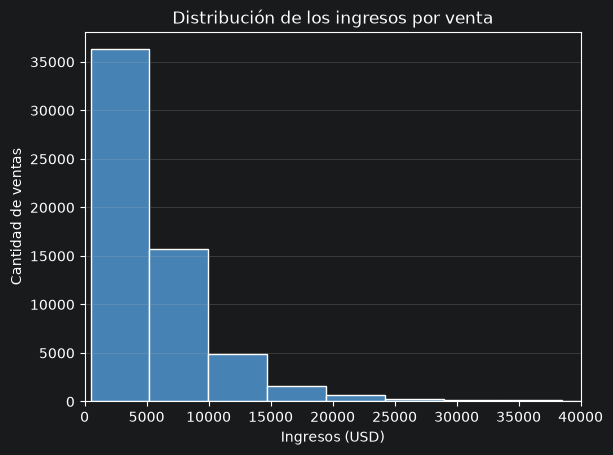

In [6]:
import matplotlib.pyplot as plt

df["sales_revenue_usd"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white")
plt.title("Distribución de los ingresos por venta")
plt.xlabel("Ingresos (USD)")
plt.ylabel("Cantidad de ventas")
plt.xlim(0, 40000)   # enfoca la zona donde está la gran mayoría de las ventas
plt.grid(axis="y", alpha=0.3)
plt.show()

El histograma muestra cómo se reparten los ingresos entre todas las ventas. La gran mayoría se encuentra alrededor de los USD 5.000,00.

Por otra parte, notamos que existen casos atípicos de ingresos altos, lo cual visualizamos dado que los datos se encuentran **sesgados a la derecha**. A raíz de esto fue que, durante la
limpieza, usamos la mediana en lugar del promedio: esas pocas ventas muy grandes
elevarían el promedio y darían una imagen distorsionada de lo "típico", mientras
que la mediana representa mejor al grueso de las ventas.

### 3.2 ¿Qué variables se relacionan con los ingresos?

Medimos el grado de relación entre cada variable numérica y los ingresos
(en una escala donde 1 sería una relación perfecta y 0 ninguna relación).

El resultado nos muestra que las tres variables de **inversión en marketing** (ad_spend_online_usd, ad_spend_offline_usd y marketing_budget_usd)
son, por amplia diferencia, las más relacionadas con los ingresos (valores
cercanos a 0,7). En cambio, factores como la edad del cliente, la satisfacción
o los seguidores en redes mostraron una relación prácticamente nula.

In [7]:
df.corr(numeric_only=True)["sales_revenue_usd"].sort_values(ascending=False)

sales_revenue_usd              1.000000
ad_spend_online_usd            0.698200
ad_spend_offline_usd           0.679897
marketing_budget_usd           0.656171
num_previous_purchases         0.048060
conversion_rate                0.039513
customer_satisfaction_score    0.039404
num_promotions                 0.037726
website_traffic                0.017426
customer_age                   0.006021
email_open_rate                0.004430
id                            -0.000340
social_media_followers        -0.001325
num_sales_representatives     -0.003491
days_since_last_purchase      -0.009812
competitor_price_index        -0.017224
discount_percentage           -0.021929
Name: sales_revenue_usd, dtype: float64

### 3.3 Inversión en marketing frente a ingresos

Llegamos al gráfico central del informe: relacionamos directamente la inversión
en marketing con los ingresos. Cada punto será una venta, ubicada según cuánto se
invirtió (eje horizontal) y cuánto generó (eje vertical). Agregamos una línea de
tendencia para ver hacia dónde apunta el conjunto.

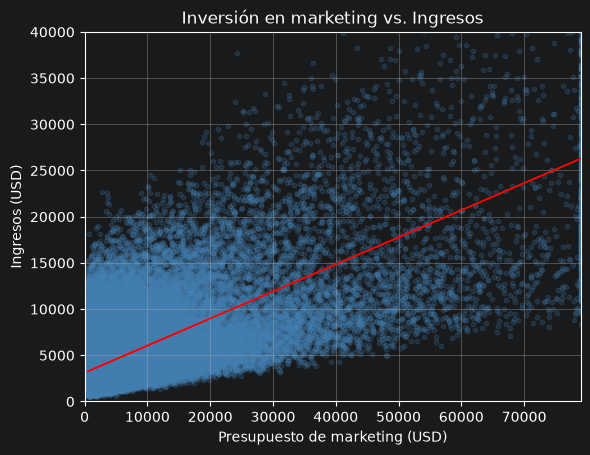

In [8]:
import numpy as np

df.plot(kind="scatter", x="marketing_budget_usd", y="sales_revenue_usd",
        alpha=0.2, s=10, color="steelblue")

x = df["marketing_budget_usd"]
y = df["sales_revenue_usd"]
pendiente, ordenada = np.polyfit(x, y, 1)
plt.plot(x, pendiente * x + ordenada, color="red", linewidth=1)
plt.title("Inversión en marketing vs. Ingresos")
plt.xlabel("Presupuesto de marketing (USD)")
plt.ylabel("Ingresos (USD)")
plt.xlim(0, 79000)   # enfoca el rango real y no considera los ingresos atípicos
plt.ylim(0, 40000)   # la gran mayoría de los ingresos está por debajo de 40.000
plt.grid(alpha=0.5)
plt.show()

Este gráfico es la respuesta visual a la pregunta central del informe. La línea
roja es la **tendencia general**.

Esa línea asciende con claridad hacia la derecha: **a mayor presupuesto de
marketing, mayores ingresos por venta**. Confirma visualmente la relación positiva
que ya habíamos detectado en la tabla de correlaciones.

Se observa además que, con presupuestos bajos, los ingresos son bajos y bastante
previsibles; en cambio, con presupuestos altos los ingresos tienden a ser mayores
pero también más variables. Una mayor inversión abre la posibilidad de mayores
ingresos, aunque no los garantiza.

Para que la relación se lea con claridad, enfocamos la vista del gráfico en el
rango donde se concentra la gran mayoría de las ventas (ingresos por debajo de
40.000 USD). Las ventas atípicas no están representadas visualmente en el gráfica ya que son un porcentaje menor de la muestra.


### 3.4 ¿Qué canal genera más ingresos?

Como análisis complementario, comparamos el ingreso promedio por venta según el
canal.


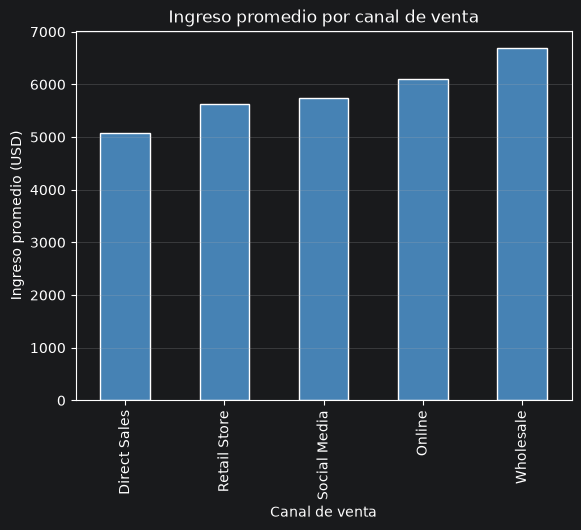

In [9]:
# Calcular el ingreso promedio por canal de venta
ventas_por_canal = df.groupby("sales_channel")["sales_revenue_usd"].mean().sort_values()

# Graficar en barras
ventas_por_canal.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Ingreso promedio por canal de venta")
plt.xlabel("Canal de venta")
plt.ylabel("Ingreso promedio (USD)")
plt.grid(axis="y", alpha=0.3)
plt.show()

El gráfico de barras muestra que **Wholesale es el canal con mayor ingreso
promedio** (~6.700 USD por venta), seguido por Online (~6.100). En el otro extremo,
Direct Sales es el de menor ingreso promedio (~5.100 USD). La diferencia entre el
canal más y el menos rentable ronda los 1.600 USD por venta.


## 4. Conclusiones